# Circuit Simulator

In [1]:
from timeit import default_timer

from tn4qa.circuit_simulator import CircuitSimulator
from tn4qa.quantum_algorithms.variational.ansatz_circuits import (
    random_brickwork_circuit,
)

/Users/angusmingare/Library/Caches/pypoetry/virtualenvs/tn4qa-cqx8VMJt-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
nqs = [4, 8, 12, 16]
ls = [4, 8, 12, 24]
qpgs = [2, 3]

results = {
    x: {
        "nq": None,
        "l": None,
        "qpg": None,
        "circuit_construction_time": None,
        "circuit_execution_time": None,
        "total_time": None,
    }
    for x in range(len(nqs) * len(ls) * len(qpgs))
}
idx = 0
for nq in nqs:
    for l in ls:
        for qpg in qpgs:
            print(f"starting {nq} qubits, {l} layers, {qpg}-qubit gates")
            qc = random_brickwork_circuit(nq, l, qpg)

            start = default_timer()
            sim = CircuitSimulator(qc)
            end1 = default_timer()
            state = sim.run(max_bond_dimension=128)
            end2 = default_timer()

            results[idx]["nq"] = nq
            results[idx]["l"] = l
            results[idx]["qpg"] = qpg
            results[idx]["circuit_construction_time"] = end1 - start
            results[idx]["circuit_execution_time"] = end2 - end1
            results[idx]["total_time"] = end2 - start
            idx += 1

starting 4 qubits, 4 layers, 2-qubit gates
starting 4 qubits, 4 layers, 3-qubit gates
starting 4 qubits, 8 layers, 2-qubit gates
starting 4 qubits, 8 layers, 3-qubit gates
starting 4 qubits, 12 layers, 2-qubit gates
starting 4 qubits, 12 layers, 3-qubit gates
starting 4 qubits, 24 layers, 2-qubit gates
starting 4 qubits, 24 layers, 3-qubit gates
starting 8 qubits, 4 layers, 2-qubit gates
starting 8 qubits, 4 layers, 3-qubit gates
starting 8 qubits, 8 layers, 2-qubit gates
starting 8 qubits, 8 layers, 3-qubit gates
starting 8 qubits, 12 layers, 2-qubit gates
starting 8 qubits, 12 layers, 3-qubit gates
starting 8 qubits, 24 layers, 2-qubit gates
starting 8 qubits, 24 layers, 3-qubit gates
starting 12 qubits, 4 layers, 2-qubit gates
starting 12 qubits, 4 layers, 3-qubit gates
starting 12 qubits, 8 layers, 2-qubit gates
starting 12 qubits, 8 layers, 3-qubit gates
starting 12 qubits, 12 layers, 2-qubit gates
starting 12 qubits, 12 layers, 3-qubit gates
starting 12 qubits, 24 layers, 2-qubit

KeyboardInterrupt: 

In [8]:
import matplotlib.pyplot as plt

In [15]:
# Plot total time vs. num qubits for each l

times_2q_gates = {nq: {l: None for l in ls} for nq in nqs}
times_3q_gates = {nq: {l: None for l in ls} for nq in nqs}
for didx in range(32):
    d = results[didx]
    nq = d["nq"]
    l = d["l"]
    qpg = d["qpg"]
    if qpg == 2:
        times_2q_gates[nq][l] = d["total_time"]
    else:
        times_3q_gates[nq][l] = d["total_time"]

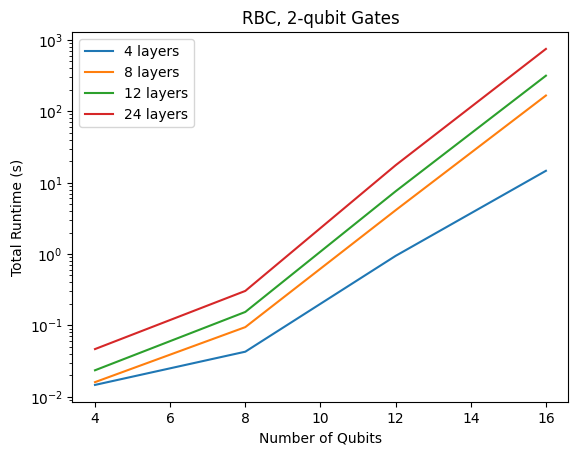

In [17]:
for l in ls:
    plt.plot(nqs, [times_2q_gates[nq][l] for nq in nqs], label=f"{l} layers")
plt.xlabel("Number of Qubits")
plt.ylabel("Total Runtime (s)")
plt.yscale("log")
plt.title("RBC, 2-qubit Gates")
plt.legend()
plt.show()

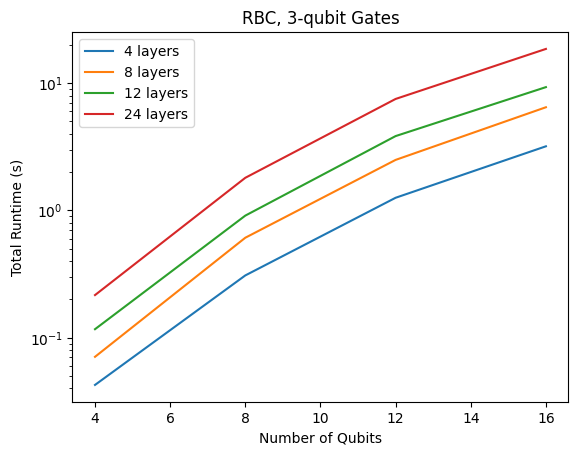

In [18]:
for l in ls:
    plt.plot(nqs, [times_3q_gates[nq][l] for nq in nqs], label=f"{l} layers")
plt.xlabel("Number of Qubits")
plt.ylabel("Total Runtime (s)")
plt.yscale("log")
plt.title("RBC, 3-qubit Gates")
plt.legend()
plt.show()

In [19]:
# Plot QV vs. total runtime

times_2q_gates = []
times_3q_gates = []

for didx in range(32):
    d = results[didx]
    nq = d["nq"]
    l = d["l"]
    qpg = d["qpg"]
    qv = nq * 2 * l
    time = d["total_time"]
    if qpg == 2:
        times_2q_gates.append((qv, time))
    else:
        times_3q_gates.append((qv, time))

times_2q_gates.sort(key=lambda x: x[0])
times_3q_gates.sort(key=lambda x: x[0])

/var/folders/hx/_6t_j_f1057_stsrthxfpfsw0000gn/T/ipykernel_79009/700239604.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


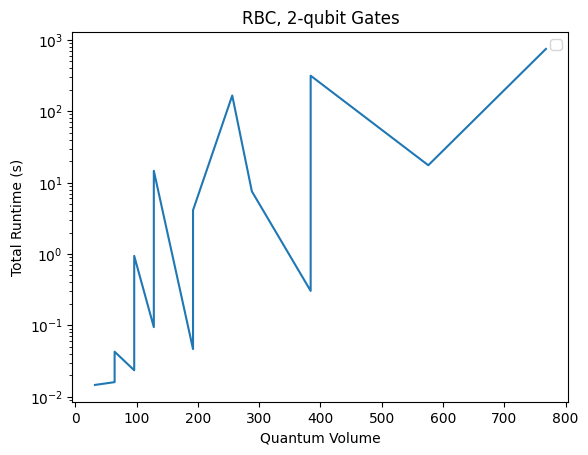

In [21]:
plt.plot(
    [times_2q_gates[i][0] for i in range(len(times_2q_gates))],
    [times_2q_gates[i][1] for i in range(len(times_2q_gates))],
)
plt.xlabel("Quantum Volume")
plt.ylabel("Total Runtime (s)")
plt.yscale("log")
plt.title("RBC, 2-qubit Gates")
plt.legend()
plt.show()

/var/folders/hx/_6t_j_f1057_stsrthxfpfsw0000gn/T/ipykernel_79009/1717050652.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


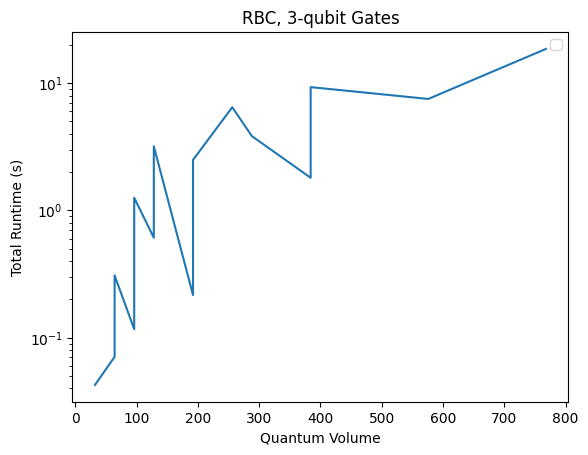

In [22]:
plt.plot(
    [times_3q_gates[i][0] for i in range(len(times_3q_gates))],
    [times_3q_gates[i][1] for i in range(len(times_3q_gates))],
)
plt.xlabel("Quantum Volume")
plt.ylabel("Total Runtime (s)")
plt.yscale("log")
plt.title("RBC, 3-qubit Gates")
plt.legend()
plt.show()